In [7]:
%matplotlib inline
import warnings

# Keep sklearn's parallel warning propagation initialized.
if not warnings.filters:
    warnings.simplefilter("default")

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
import statsmodels.formula.api as smf
from pathlib import Path

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "pyproject.toml").exists()),
    Path.cwd(),
)
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "unadjusted_vs_random"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = OUTPUT_DIR / "unadjusted_vs_random_results.csv"

In [8]:
def spline_pvalue(formula, data, variance, sigma):
    result = smf.ols(formula, data=data).fit()
    if variance == "unknown":
        return result.f_pvalue
    statistic = result.ess / sigma**2
    return stats.chi2.sf(statistic, df=int(result.df_model))


def run_simulation(
    n_iters, n_samples, n_features, k_select, alpha=0.05, seed=123,
    variance="unknown", sigma=1.0, rf_params=None, verbose=True,
    show_progress=False, progress_desc=None,
):
    if n_iters < 2 or n_samples <= 4 or n_features < 1:
        raise ValueError("Use n_iters >= 2, n_samples > 4, and n_features >= 1.")
    k_values = np.atleast_1d(k_select).tolist()
    if any(not isinstance(k, (int, np.integer)) for k in k_values):
        raise ValueError("Every k_select value must be an integer.")
    k_values = sorted(set(int(k) for k in k_values))
    if not k_values or any(not 1 <= k <= n_features for k in k_values) or not 0 < alpha < 1:
        raise ValueError("Require 1 <= k_select <= n_features and 0 < alpha < 1.")
    max_k = max(k_values)
    if variance not in {"unknown", "known"}:
        raise ValueError("variance must be either 'unknown' or 'known'.")
    if sigma <= 0:
        raise ValueError("sigma must be positive.")
    # Keep the forest configuration in one adjustable dictionary.
    forest_params = {"n_estimators": 50, "max_depth": 5, "random_state": 42}
    if rf_params is not None:
        forest_params.update(dict(rf_params))
    data_seed, random_seed = np.random.SeedSequence(seed).spawn(2)
    data_rng = np.random.default_rng(data_seed)
    random_rng = np.random.default_rng(random_seed)
    pvals_shap = []
    pvals_random = []
    
    iterations = tqdm(
        range(n_iters), desc=progress_desc or f"{variance} variance",
        unit="iteration", leave=True, disable=not show_progress,
    )
    for _ in iterations:
        # [1] Generate data under the global null hypothesis.
        X = data_rng.standard_normal((n_samples, n_features))
        y = sigma * data_rng.standard_normal(n_samples)
        
        df = pd.DataFrame(X, columns=[f"x{i}" for i in range(n_features)])
        df["y"] = y
        
        # [2] Fit a random forest and compute SHAP importance scores.
        model = RandomForestRegressor(**forest_params)
        model.fit(X, y)
        
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        
        # [3] Select features using SHAP importance and random sampling.
        # Random selection
        random_selected_idx = random_rng.permutation(n_features)[:max_k]
        # SHAP-based selection
        shap_selected_idx = np.lexsort((np.arange(n_features), -mean_abs_shap))[:max_k]
        
        # [4] Run the B-spline test after random selection.
        for idx in random_selected_idx:
            formula = f"y ~ bs(x{idx}, df=3)"
            pvals_random.append(spline_pvalue(formula, df, variance, sigma))
        
        # [5] Run the unadjusted test after SHAP-based selection.
        for idx in shap_selected_idx:
            formula = f"y ~ bs(x{idx}, df=3)"
            pvals_shap.append(spline_pvalue(formula, df, variance, sigma))

    # [6] Calculate the empirical false-positive rate (FPR).
    pvals_shap = np.array(pvals_shap)
    pvals_random = np.array(pvals_random)
    
    shap_rejections = (pvals_shap < alpha).reshape(n_iters, max_k)
    random_rejections = (pvals_random < alpha).reshape(n_iters, max_k)
    rows = []
    for k in k_values:
        shap_rates = shap_rejections[:, :k].mean(axis=1)
        random_rates = random_rejections[:, :k].mean(axis=1)
        rows.extend([
            {"variance": variance, "k_select": k, "method": "Random baseline",
             "fpr": random_rates.mean(), "se": random_rates.std(ddof=1) / np.sqrt(n_iters)},
            {"variance": variance, "k_select": k, "method": "Unadjusted post-SHAP",
             "fpr": shap_rates.mean(), "se": shap_rates.std(ddof=1) / np.sqrt(n_iters)},
        ])
    summary = pd.DataFrame(rows)
    if verbose:
        print(f"\n=== Simulation Results: {variance} variance ===")
        display(summary)
    
    # Store one row per method and selection size.
    return {"variance": variance, "sigma": sigma, "k_values": k_values,
            "rf_params": forest_params.copy(),
            "pvals_shap": pvals_shap.reshape(n_iters, max_k),
            "pvals_random": pvals_random.reshape(n_iters, max_k),
            "summary": summary}

In [9]:
K_SELECT_VALUES = list(range(1, 11))
N_ITERS = 1000  # Use 100 for a quick check before the full experiment.

# Add or edit named configurations to test other RandomForestRegressor settings.
RF_CONFIGS = {
    "baseline": {
        "n_estimators": 50, "max_depth": 5,
        "min_samples_leaf": 1, "max_features": 1.0,
    },
    "larger_forest": {
        "n_estimators": 200, "max_depth": None,
        "min_samples_leaf": 1, "max_features": 1.0,
    },
    "regularized_forest": {
        "n_estimators": 100, "max_depth": 3,
        "min_samples_leaf": 5, "max_features": 0.7,
    },
}

# These shared options make every configuration reproducible and parallelize fitting.
RF_SHARED_PARAMS = {"random_state": 42, "n_jobs": -1}

results = {}
for rf_name, config in RF_CONFIGS.items():
    rf_params = {**RF_SHARED_PARAMS, **config}
    for variance in ("unknown", "known"):
        result = run_simulation(
            n_iters=N_ITERS, n_samples=100, n_features=20,
            k_select=K_SELECT_VALUES, seed=123, variance=variance, sigma=1.0,
            rf_params=rf_params, verbose=False, show_progress=True,
            progress_desc=f"{rf_name} | {variance}",
        )
        result["summary"] = result["summary"].assign(rf_config=rf_name)
        results[(rf_name, variance)] = result

combined_results = pd.concat(
    [result["summary"] for result in results.values()], ignore_index=True
)
combined_results.to_csv(RESULTS_CSV, index=False)
print(f"Saved simulation results to {RESULTS_CSV}")
display(combined_results)

baseline | unknown: 100%|██████████| 1000/1000 [02:47<00:00,  5.96iteration/s]
baseline | known: 100%|██████████| 1000/1000 [02:25<00:00,  6.86iteration/s]
larger_forest | unknown: 100%|██████████| 1000/1000 [08:19<00:00,  2.00iteration/s]
larger_forest | known: 100%|██████████| 1000/1000 [07:47<00:00,  2.14iteration/s]
regularized_forest | unknown: 100%|██████████| 1000/1000 [03:03<00:00,  5.44iteration/s]
regularized_forest | known: 100%|██████████| 1000/1000 [03:11<00:00,  5.22iteration/s]

Saved simulation results to c:\Users\shida\OneDrive\selective-inference\shap-selective-inference\outputs\unadjusted_vs_random\unadjusted_vs_random_results.csv


,variance,k_select,method,fpr,se,rf_config
0,unknown,1,Random baseline,0.051000,0.006960,baseline
1,unknown,1,Unadjusted post-SHAP,0.361000,0.015196,baseline
2,unknown,2,Random baseline,0.048000,0.004714,baseline
3,unknown,2,Unadjusted post-SHAP,0.269000,0.010136,baseline
4,unknown,3,Random baseline,0.050667,0.003987,baseline
...,...,...,...,...,...,...
115,known,8,Unadjusted post-SHAP,0.102375,0.003582,regularized_forest
116,known,9,Random baseline,0.047667,0.002355,regularized_forest
117,known,9,Unadjusted post-SHAP,0.093889,0.003273,regularized_forest
118,known,10,Random baseline,0.047700,0.002254,regularized_forest


In [10]:
# Reload the saved results so this analysis does not depend on simulation state.
analysis_results = pd.read_csv(RESULTS_CSV)

# Quantify how much each configuration differs from the baseline forest.
FPR_TOLERANCE = 0.02  # Define 'similar' as no FPR difference larger than 2 points.
comparison_keys = ["variance", "k_select", "method"]
baseline_fpr = (
    analysis_results.loc[analysis_results["rf_config"] == "baseline", comparison_keys + ["fpr"]]
    .rename(columns={"fpr": "baseline_fpr"})
)
comparison = analysis_results.merge(baseline_fpr, on=comparison_keys, how="left")
comparison["fpr_difference"] = comparison["fpr"] - comparison["baseline_fpr"]
comparison["absolute_difference"] = comparison["fpr_difference"].abs()

similarity_summary = (
    comparison.groupby(["rf_config", "variance", "method"], as_index=False)
    .agg(mean_absolute_difference=("absolute_difference", "mean"),
         max_absolute_difference=("absolute_difference", "max"))
)
similarity_summary["similar_to_baseline"] = (
    similarity_summary["max_absolute_difference"] <= FPR_TOLERANCE
)
fpr_pivot = comparison.pivot(
    index="k_select", columns=["variance", "method", "rf_config"], values="fpr"
)
comparison.to_csv(
    OUTPUT_DIR / "unadjusted_vs_random_comparison.csv", index=False
)
similarity_summary.to_csv(
    OUTPUT_DIR / "unadjusted_vs_random_similarity_summary.csv", index=False
)
fpr_pivot.to_csv(OUTPUT_DIR / "unadjusted_vs_random_fpr_pivot.csv")
display(similarity_summary)
display(fpr_pivot)

,rf_config,variance,method,mean_absolute_difference,max_absolute_difference,similar_to_baseline
0,baseline,known,Random baseline,0.000000,0.000000,True
1,baseline,known,Unadjusted post-SHAP,0.000000,0.000000,True
2,baseline,unknown,Random baseline,0.000000,0.000000,True
3,baseline,unknown,Unadjusted post-SHAP,0.000000,0.000000,True
4,larger_forest,known,Random baseline,0.000000,0.000000,True
5,larger_forest,known,Unadjusted post-SHAP,0.001430,0.007000,True
6,larger_forest,unknown,Random baseline,0.000000,0.000000,True
7,larger_forest,unknown,Unadjusted post-SHAP,0.002260,0.006333,True
8,regularized_forest,known,Random baseline,0.000000,0.000000,True
9,regularized_forest,known,Unadjusted post-SHAP,0.008048,0.016000,True


variance          unknown                                known  \
method    Random baseline Unadjusted post-SHAP Random baseline   
rf_config        baseline             baseline        baseline   
k_select                                                         
1                0.051000             0.361000        0.055000   
2                0.048000             0.269000        0.050000   
3                0.050667             0.215000        0.049000   
4                0.050250             0.181500        0.047500   
5                0.050600             0.157400        0.048400   
6                0.050500             0.137667        0.047667   
7                0.051286             0.122857        0.048000   
8                0.050750             0.109750        0.048875   
9                0.050111             0.099778        0.047667   
10               0.049900             0.091200        0.047700   

variance                               unknown                       \
method    Unadjusted post-SHAP Random baseline Unadjusted post-SHAP   
rf_config             baseline   larger_forest        larger_forest   
k_select                                                              
1                     0.347000        0.051000             0.356000   
2                     0.261000        0.048000             0.274000   
3                     0.206000        0.050667             0.221333   
4                     0.173250        0.050250             0.183000   
5                     0.150200        0.050600             0.157200   
6                     0.132167        0.050500             0.139167   
7                     0.119143        0.051286             0.123571   
8                     0.107000        0.050750             0.111125   
9                     0.097111        0.050111             0.100556   
10                    0.088900        0.049900             0.091400   

variance            known                                 unknown  \
method    Random baseline Unadjusted post-SHAP    Random baseline   
rf_config   larger_forest        larger_forest regularized_forest   
k_select                                                            
1                0.055000             0.340000           0.051000   
2                0.050000             0.261500           0.048000   
3                0.049000             0.209333           0.050667   
4                0.047500             0.173750           0.050250   
5                0.048400             0.150400           0.050600   
6                0.047667             0.133667           0.050500   
7                0.048000             0.119000           0.051286   
8                0.048875             0.107375           0.050750   
9                0.047667             0.097556           0.050111   
10               0.047700             0.089200           0.049900   

variance                                    known                       
method    Unadjusted post-SHAP    Random baseline Unadjusted post-SHAP  
rf_config   regularized_forest regularized_forest   regularized_forest  
k_select                                                                
1                     0.339000           0.055000             0.331000  
2                     0.257000           0.050000             0.248000  
3                     0.203333           0.049000             0.195000  
4                     0.173000           0.047500             0.165500  
5                     0.148600           0.048400             0.142200  
6                     0.130000           0.047667             0.125000  
7                     0.116429           0.048000             0.112429  
8                     0.105250           0.048875             0.102375  
9                     0.096778           0.047667             0.093889  
10                    0.088900           0.047700             0.085900

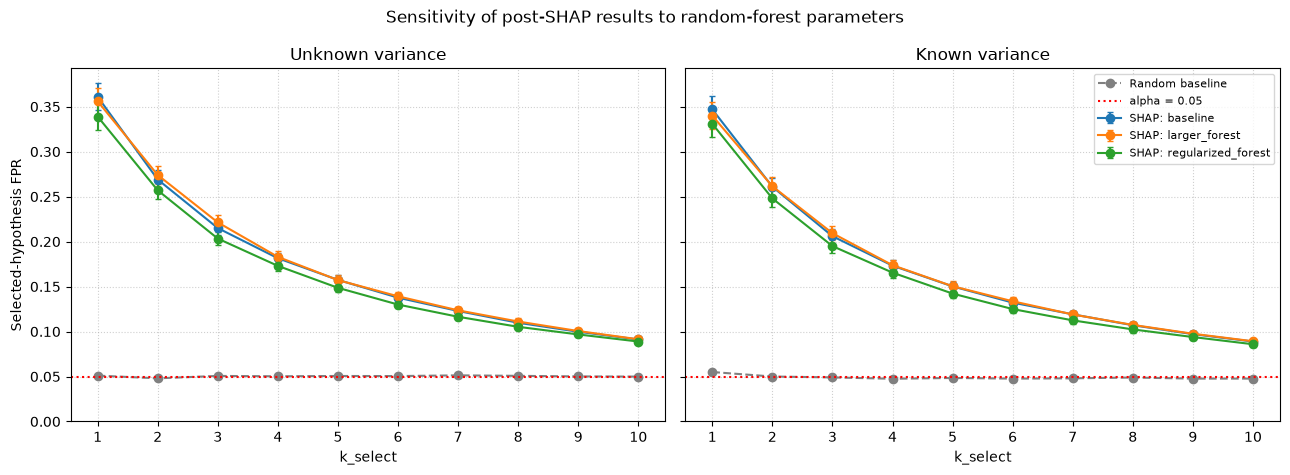

In [11]:
# Plot only from the saved CSV; rerunning the simulation is not required.
plot_results = pd.read_csv(RESULTS_CSV)
required_columns = {"variance", "k_select", "method", "fpr", "se", "rf_config"}
missing_columns = required_columns.difference(plot_results.columns)
if missing_columns:
    raise ValueError(f"Results CSV is missing columns: {sorted(missing_columns)}")
plot_k_values = sorted(plot_results["k_select"].unique())

# The random baseline is identical across forest settings, so plot it once per panel.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, variance in zip(axes, ["unknown", "known"]):
    panel = plot_results[plot_results["variance"] == variance]
    random_line = panel[(panel["method"] == "Random baseline") &
                        (panel["rf_config"] == "baseline")].sort_values("k_select")
    ax.plot(random_line["k_select"], random_line["fpr"],
            color="gray", linestyle="--", marker="o", label="Random baseline")
    shap_panel = panel[panel["method"] == "Unadjusted post-SHAP"]
    for rf_name, group in shap_panel.groupby("rf_config", sort=False):
        group = group.sort_values("k_select")
        ax.errorbar(group["k_select"], group["fpr"], yerr=group["se"],
                    marker="o", capsize=2, label=f"SHAP: {rf_name}")
    ax.axhline(0.05, color="red", linestyle=":", linewidth=1.5, label="alpha = 0.05")
    ax.set(title=f"{variance.capitalize()} variance", xlabel="k_select",
           xticks=plot_k_values)
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle=":", alpha=0.6)
axes[0].set_ylabel("Selected-hypothesis FPR")
axes[1].legend(fontsize=8)
fig.suptitle("Sensitivity of post-SHAP results to random-forest parameters")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "unadjusted_vs_random_rf_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()